# PROJECT | DEEP LEARNING

**Clasificación de imagenes usando CNN y Transfer Learning.**

##**1. DATA PREPROCESSING**

In [ ]:
# IMPORTACIONES Y CONFIGURACIÓN DE REPRODUCIBILIDAD
# =================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

import os

np.random.seed(1)
tf.random.set_seed(1)



In [ ]:
from tensorflow.keras.datasets import cifar10

# CARGAR DATASET
# ==============

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
from sklearn.model_selection import train_test_split

# NORMALIZAR IMÁGENES
# ===================

X_train = X_train / 255.0
X_test = X_test / 255.0

# CREAR CONJUNTO DE VALIDACIÓN
# ============================

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,     # 25% de 80% = 20% del total
    random_state=1,     # Semilla para reproducibilidad
    stratify=y_train    # Mantener proporción de clases
)


print("\n================ CONJUNTOS FINALES ================")
print(f"x_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")
print(f"x_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")







================ CONJUNTOS FINALES ================
x_train: (37500, 32, 32, 3)
y_train: (37500, 1)
x_val:   (12500, 32, 32, 3)
y_val:   (12500, 1)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 1)


In [ ]:
# CONVERTIR LABELS A ONE-HOT ENCODING
# ===================================

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)  # 10 clases
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

print("\n================DESPUÉS DE ONE-HOT================")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")


================DESPUÉS DE ONE-HOT================
y_train: (37500, 10)
y_val:   (12500, 10)
y_test:  (10000, 10)


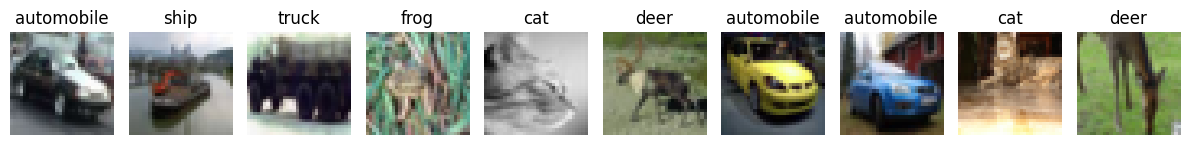

In [ ]:
# VISUALIZACIÓN DE EJEMPLOS
#==========================

# Nombres de las clases de CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Mostrar 10 imágenes de ejemplo
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i])
    # Encontrar el índice de la clase (deshacer one-hot)
    class_idx = np.argmax(y_train[i])
    plt.title(class_names[class_idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

##**2. MODEL ARCHITECTURE**


In [ ]:
# CONSTRUCCIÓN DEL MODELO CNN CON GLOBALAVERAGEPOOLING2D
# ======================================================

model = Sequential()                             # Crear modelo secuencial

model.add(Input(shape=(32, 32, 3)))              # Capa entrada: forma de las imágenes (28×28×1)

model.add(Conv2D(32, (3, 3), activation='relu')) # 1ra capa conv.: 32 filtros, kernel de 3×3, ReLU
model.add(MaxPooling2D((2, 2)))                  # 1ra capa pooling: MaxPooling con poolsize de 2×2
model.add(Dropout(0.25))                         # Dropout del 25%

model.add(Conv2D(64, (3, 3), activation='relu')) # 2da capa conv.: 64 filtros, kernel de 3×3, ReLU
model.add(MaxPooling2D((2, 2)))                  # 2da capa pooling: MaxPooling con poolsize de 2×2
model.add(Dropout(0.25))                         # Dropout del 25%

model.add(Conv2D(128, (3, 3), activation='relu')) # 3ra capa conv.: 128 filtros, kernel de 3×3, ReLU
model.add(MaxPooling2D((2, 2)))                  # 3ra capa pooling: MaxPooling con poolsize de 2×2
model.add(Dropout(0.25))                         # Dropout del 25%

model.add(GlobalAveragePooling2D())              # GlobalAveragePooling2D: promedio de c/ feature map
                                                 # backbone fuerte, head liviana!
model.add(Dense(256, activation='relu'))         # 1ra capa oculta: 256 neuronas, ReLU
model.add(Dropout(0.45))                         # Dropout del 45%

model.add(Dense(10, activation='softmax'))       # Capa salida: 10 neuronas (dígito 0-9), Softmax

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,842 (503.29 KB)

 Trainable params: 128,842 (503.29 KB)

 Non-trainable params: 0 (0.00 B)

##3.ENTRENAMIENTO DEL MODELO

In [ ]:
# ENTRENAMIENTO DEL MODELO
# ========================

model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=16,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=200,
    verbose=1,
    validation_data=(X_val, y_val)
    callbacks=[early_stop])


Epoch 1/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.1594 - loss: 2.2030 - val_accuracy: 0.2749 - val_loss: 1.9145
Epoch 2/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 79s 95ms/step - accuracy: 0.2914 - loss: 1.8635 - val_accuracy: 0.3937 - val_loss: 1.6475
Epoch 3/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 81s 94ms/step - accuracy: 0.3759 - loss: 1.6649 - val_accuracy: 0.4704 - val_loss: 1.4774
Epoch 4/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 56s 96ms/step - accuracy: 0.4380 - loss: 1.5359 - val_accuracy: 0.5176 - val_loss: 1.3462
Epoch 5/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 62s 105ms/step - accuracy: 0.4807 - loss: 1.4326 - val_accuracy: 0.5570 - val_loss: 1.2648
Epoch 6/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 57s 97ms/step - accuracy: 0.5093 - loss: 1.3604 - val_accuracy: 0.5697 - val_loss: 1.2261
Epoch 7/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 79s 93ms/step - accuracy: 0.5300 - loss: 1.3019 - val_accuracy: 0.5846 - val_loss: 1.1859
Epoch 8/200
586/586 ━━━━━━━━━━━━━━━━━━━━ 56s 95ms/step - accuracy: 0.5534 - loss:

              precision    recall  f1-score   support

    airplane       0.78      0.80      0.79      1000
  automobile       0.89      0.88      0.89      1000
        bird       0.71      0.62      0.66      1000
         cat       0.62      0.53      0.57      1000
        deer       0.74      0.75      0.75      1000
         dog       0.70      0.66      0.68      1000
        frog       0.69      0.91      0.79      1000
       horse       0.81      0.79      0.80      1000
        ship       0.87      0.86      0.87      1000
       truck       0.83      0.85      0.84      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.76     10000
weighted avg       0.77      0.77      0.76     10000



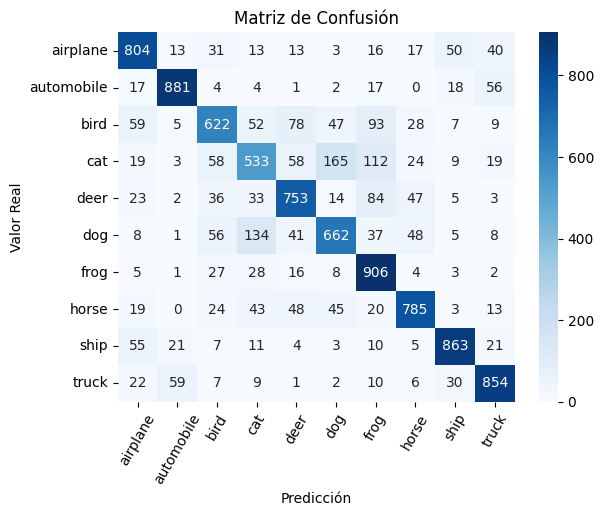

In [ ]:
# PREDICCIONES EN TEST SET
# ========================

# argmax devuelve el índice del valor máximo (la clase con mayor probabilidad)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convertir y_test de one-hot a etiquetas
y_test_labels = np.argmax(y_test, axis=1)  # Clase real (0-9)

# Classification Report
report = classification_report(y_test_labels, y_pred, target_names=class_names)
print(report)

# Matriz de Confusión
cm = confusion_matrix(y_test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.show()

##4.VISUALIZACIÓN DE CURVAS DE APRENDIZAJE

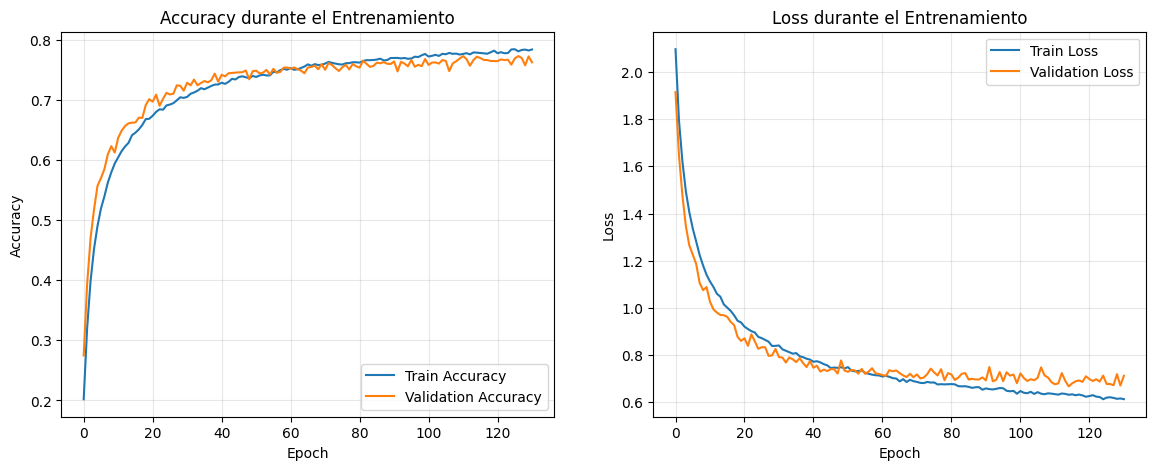

TRAIN:
Loss óptimo: 0.6318
Accuracy óptimo: 77.85%
Loss final: 0.6133
Accuracy final: 78.38%

VALIDATION:
Loss óptimo: 0.6673
Accuracy óptimo: 77.18%
Loss final: 0.7125
Accuracy final: 76.24%


In [ ]:
# VISUALIZACIÓN DE CURVAS DE APRENDIZAJE
# ======================================

# Crear figura con 2 subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy durante el Entrenamiento')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss durante el Entrenamiento')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.show()

# Mostrar valores de entrenamiento
best_epoch = np.argmin(history.history['val_loss'])
print(f"TRAIN:")
print(f"Loss óptimo: {history.history['loss'][best_epoch]:.4f}")
print(f"Accuracy óptimo: {history.history['accuracy'][best_epoch]*100:.2f}%")
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['accuracy'][-1]*100:.2f}%")
print()
print(f"VALIDATION:")
print(f"Loss óptimo: {history.history['val_loss'][best_epoch]:.4f}")
print(f"Accuracy óptimo: {history.history['val_accuracy'][best_epoch]*100:.2f}%")
print(f"Loss final: {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['val_accuracy'][-1]*100:.2f}%")

##5.VISUALIZACIÓN DE PREDICCIONES

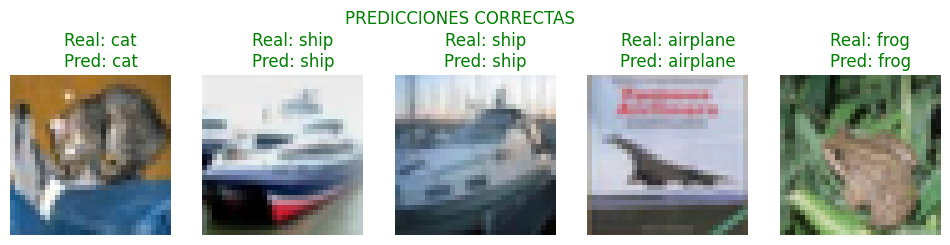

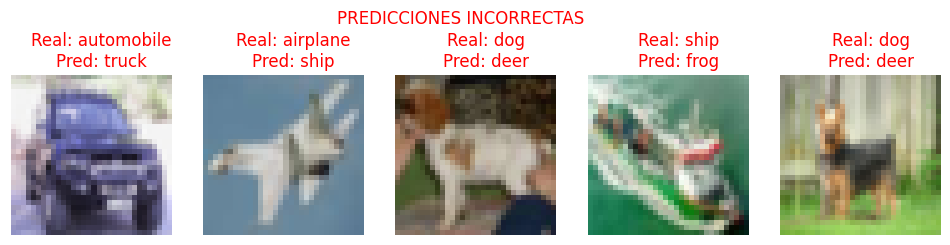

In [ ]:
# VISUALIZACIÓN DE PREDICCIONES
# =============================

# Encontrar predicciones correctas e incorrectas
correct_indices = np.where(y_pred == y_test_labels)[0]    # Índices correctos
incorrect_indices = np.where(y_pred != y_test_labels)[0]  # Índices incorrectos - Corregido y_test a y_test_labels

# Visualizar 5 predicciones correctas
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes = axes.flatten()  # Convertir en array 1D

for i in range(0, 5):
    idx = correct_indices[i]
    # Corregido: Reshape a (32, 32, 3) para imágenes RGB o simplemente usar sin reshape
    axes[i].imshow(X_test[idx].reshape(32, 32, 3), cmap='gray')  # O quitar reshape si no es necesario
    axes[i].set_title(f"""
    Real: {class_names[y_test_labels[idx]]}
    Pred: {class_names[y_pred[idx]]}""",color='green')
    axes[i].axis('off')
plt.suptitle('PREDICCIONES CORRECTAS', color='green')
plt.show()

# Visualizar 5 predicciones incorrectas
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes = axes.flatten()  # Convertir en array 1D

for i in range(0, 5):
    idx = incorrect_indices[i]
    # Corregido: Cambiado x_test a X_test para consistencia y corregido el reshape
    axes[i].imshow(X_test[idx].reshape(32, 32, 3), cmap='gray')  # Ajustado a la misma forma que arriba
    axes[i].set_title(f"""
    Real: {class_names[y_test_labels[idx]]}
    Pred: {class_names[y_pred[idx]]}""",color='red')
    axes[i].axis('off')
plt.suptitle('PREDICCIONES INCORRECTAS', color='red')
plt.show()